# `tab:data_stats` — Tutoring Provider A data statistics for the working paper

Fills the `tab:data_stats` table (Tutoring Provider A *Session Data* + *Teachers' Annotations*)
from the self-contained Hugging Face release **`huggingface-release-20260630`**.

This release contains.

- `tutoring_provider_a.jsonl` — 462 transcripts (full Oct 2025-10-16 batch) → *Session Data*
- `tutoring_provider_a_annotations.jsonl` — 1,584 human SAR annotation passes (263 transcripts)
- `ground_truth_hybrid.jsonl` — 207 conversations of LLM-assisted gold; carries
  `situation_label_agg` (the scaffolding-vs-rigor gate) → *Teachers' Annotations*

Tokenization is whitespace `str.split()` throughout (matches the table caption and
`analysis/stats.ipynb`). Counting basis for moments is **unique spans**
`(conversation_id, turn_start, turn_end)`.

In [1]:
import json, os, subprocess, collections, statistics as st
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

# Repo root = two levels up from this notebook (analysis/working-paper-20260630/)
REPO = Path.cwd()
while not (REPO / ".git").exists() and REPO != REPO.parent:
    REPO = REPO.parent
DATA = REPO / "data" / "huggingface-release-20260630"
OUT_TEX = REPO / "analysis" / "working-paper-20260630" / "data_stats_table.tex"

FILES = ["tutoring_provider_a.jsonl", "tutoring_provider_a_annotations.jsonl",
         "ground_truth_hybrid.jsonl", "tutoring_provider_a.schema.json", "README.md"]

# Maintainers: set RELEASE_S3_PREFIX (e.g. s3://<bucket>/<release-prefix>) in .env
# to re-download the release inputs so the table is built from the freshest
# snapshot. Without it, already-present local files under data/ are used as-is.
S3_PREFIX = os.getenv("RELEASE_S3_PREFIX")
if S3_PREFIX:
    DATA.mkdir(parents=True, exist_ok=True)
    for f in FILES:
        print(f"download {f} ...")
        subprocess.run(["aws", "s3", "cp", f"{S3_PREFIX}/{f}", str(DATA / f)], check=True)
    # Record the snapshot (ETag + size) so the run is documented/reproducible.
    bucket, _, key_prefix = S3_PREFIX.removeprefix("s3://").partition("/")
    print("\nSnapshot (S3 ETag / size):")
    for f in FILES:
        try:
            meta = subprocess.run(
                ["aws", "s3api", "head-object", "--bucket", bucket,
                 "--key", f"{key_prefix}/{f}"],
                capture_output=True, text=True, check=True)
            j = json.loads(meta.stdout)
            print(f"  {f:28s} etag={j['ETag'].strip(chr(34))}  bytes={j['ContentLength']}")
        except Exception as e:
            print(f"  {f:28s} (head-object unavailable: {e})")

missing = [f for f in FILES if not (DATA / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Release inputs missing under {DATA}: {missing}. "
        "Download the release there, or set RELEASE_S3_PREFIX in .env.")


Completed 34.3 MiB/36.3 MiB (13.5 MiB/s) with 1 file(s) remaining  
Completed 34.6 MiB/36.3 MiB (13.5 MiB/s) with 1 file(s) remaining  
Completed 34.8 MiB/36.3 MiB (13.6 MiB/s) with 1 file(s) remaining  
Completed 35.1 MiB/36.3 MiB (13.7 MiB/s) with 1 file(s) remaining  
Completed 35.3 MiB/36.3 MiB (13.1 MiB/s) with 1 file(s) remaining  
Completed 35.6 MiB/36.3 MiB (13.2 MiB/s) with 1 file(s) remaining  
Completed 35.8 MiB/36.3 MiB (13.3 MiB/s) with 1 file(s) remaining  


Completed 36.3 MiB/36.3 MiB (12.8 MiB/s) with 1 file(s) remaining  


Completed 7.8 MiB/9.8 MiB (3.9 MiB/s) with 1 file(s) remaining    
Completed 8.0 MiB/9.8 MiB (4.0 MiB/s) with 1 file(s) remaining    
Completed 8.3 MiB/9.8 MiB (4.1 MiB/s) with 1 file(s) remaining    
Completed 8.5 MiB/9.8 MiB (4.2 MiB/s) with 1 file(s) remaining    
Completed 8.8 MiB/9.8 MiB (4.3 MiB/s) with 1 file(s) remaining    
Completed 9.0 MiB/9.8 MiB (4.5 MiB/s) with 1 file(s) remaining    
Completed 9.3 MiB/9.8 MiB (4.6 MiB/s) with 1 file(s) remaining    
Completed 9.5 MiB/9.8 MiB (4.7 MiB/s) with 1 file(s) remaining    
Completed 9.8 MiB/9.8 MiB (4.8 MiB/s) with 1 file(s) remaining    


Completed 5.0 KiB/5.0 KiB (6.5 KiB/s) with 1 file(s) remaining


Completed 9.4 KiB/9.4 KiB (12.0 KiB/s) with 1 file(s) remaining


In [2]:
def load_jsonl(name):
    with open(DATA / name) as fh:
        return [json.loads(line) for line in fh if line.strip()]

transcripts  = load_jsonl("tutoring_provider_a.jsonl")
annotations  = load_jsonl("tutoring_provider_a_annotations.jsonl")
ground_truth = load_jsonl("ground_truth_hybrid.jsonl")

print("transcripts (sessions):", len(transcripts))
print("annotation rows:", len(annotations),
      dict(collections.Counter(a["annotation_type"] for a in annotations)))
print("transcripts with any annotation:",
      len({a["transcript_id"] for a in annotations}))
print("ground_truth conversations:", len(ground_truth))
assert len(transcripts) == 462, f"expected 462 transcripts, got {len(transcripts)}"


transcripts (sessions): 462
annotation rows: 1584 {'caption': 79, 'scaffolding': 704, 'rapport': 801}
transcripts with any annotation: 263
ground_truth conversations: 207


## Section 1 — Tutoring Provider A Session Data
Computed over all **462** transcripts in `tutoring_provider_a.jsonl`.

In [3]:
def turn_tokens(t):
    return len((t.get("text") or "").split())

def duration_min(r):
    ts = r["turns"]
    starts = [t["start_seconds"] for t in ts if t.get("start_seconds") is not None]
    ends   = [t["end_seconds"]   for t in ts if t.get("end_seconds")   is not None]
    if not starts or not ends:
        return None
    return (max(ends) - min(starts)) / 60.0

n_transcripts   = len(transcripts)
avg_turns       = st.mean(len(r["turns"]) for r in transcripts)
avg_turn_tokens = st.mean(turn_tokens(t) for r in transcripts for t in r["turns"])
durations       = [d for r in transcripts if (d := duration_min(r)) is not None]
avg_duration    = st.mean(durations)
n_students      = len({r["session"].get("student_id") for r in transcripts})
n_tutors        = len({r["session"].get("tutor_id")   for r in transcripts})

# Sessions per (student, tutor) pair -> how many sessions a student has with a tutor.
pair_sessions         = collections.Counter(
    (r["session"].get("student_id"), r["session"].get("tutor_id")) for r in transcripts)
n_pairs               = len(pair_sessions)
avg_sessions_per_pair = st.mean(pair_sessions.values())

print(f"# transcripts                  : {n_transcripts}")
print(f"avg # turns / transcript       : {avg_turns:.4f}")
print(f"avg words / turn               : {avg_turn_tokens:.4f}")
print(f"avg session duration min       : {avg_duration:.4f}  (n with timing = {len(durations)})")
print(f"# students                     : {n_students}")
print(f"# tutors                       : {n_tutors}")
print(f"# (student,tutor) pairs         : {n_pairs}")
print(f"avg sessions / student-tutor pair: {avg_sessions_per_pair:.4f}"
      f"  (min {min(pair_sessions.values())}, max {max(pair_sessions.values())})")


# transcripts                  : 462
avg # turns / transcript       : 384.0866
avg words / turn               : 9.4770
avg session duration min       : 53.5010  (n with timing = 462)
# students                     : 198
# tutors                       : 173
# (student,tutor) pairs         : 198
avg sessions / student-tutor pair: 2.3333  (min 1, max 5)


## Section 2 — Teachers' Annotations

Moments come from `ground_truth_hybrid.jsonl`. A **unique key moment** is a distinct
`(conversation_id, turn_start, turn_end)` span; each span was annotated by multiple
teachers.

**Scope: this entire section is scaffolding-only — rapport annotations are excluded**
(per the paper's table). So `# of transcripts annotated` counts gold conversations with at
least one scaffolding moment, `# of annotators per moment` and `Avg # of words per SAR
annotation` are over scaffolding moments, and `situation_label_agg` (present on scaffolding
moments only, and constant within an exact span — asserted below) gives the rigor vs
scaffolding split. The cell also prints all-types figures for reference.

In [4]:
moments = [(g["conversation_id"], m) for g in ground_truth for m in g["key_moments"]]

# Group by exact span, keyed by annotation_type so we can scope scaffolding vs rapport.
spans = collections.defaultdict(list)
for cid, m in moments:
    spans[(cid, m["turn_start"], m["turn_end"], m["annotation_type"])].append(m)

scaff_spans = {k: v for k, v in spans.items() if k[3] == "scaffolding"}

def sar_tokens(m):
    return len(" ".join(str(m.get(k, "")) for k in ("situation", "action", "result")).split())

# ---- Teachers' Annotations TABLE values = SCAFFOLDING-ONLY (rapport excluded) ----
scaff_conv_ids          = {cid for cid, m in moments if m["annotation_type"] == "scaffolding"}
n_transcripts_annotated = len(scaff_conv_ids)                       # gold convs w/ >=1 scaffolding moment
n_unique_moments        = len(scaff_spans)                          # unique scaffolding spans
avg_annotators_per_mom  = st.mean(len(v) for v in scaff_spans.values())
avg_sar                 = st.mean(sar_tokens(m) for _, m in moments if m["annotation_type"] == "scaffolding")

# situation_label_agg is constant within an exact scaffolding span (assert), so the
# rigor/scaffolding split is well-defined at the span level.
inconsistent = sum(1 for v in scaff_spans.values()
                   if len({m.get("situation_label_agg") for m in v}) > 1)
assert inconsistent == 0, f"{inconsistent} scaffolding spans have inconsistent agg"
span_agg = collections.Counter(v[0].get("situation_label_agg") for v in scaff_spans.values())
n_rigor       = span_agg["rigor"]
n_scaffolding = span_agg["scaffolding"]

# ---- Reference only (ALL SAR types — not used in the table) ----
sar_gt      = [sar_tokens(m) for _, m in moments]                   # used by the diagnostic plot
avg_sar_all = st.mean(sar_gt)
avg_ann_all = st.mean(len(v) for v in spans.values())

print("TABLE (scaffolding-only):")
print(f"  # transcripts annotated (gold convs w/ scaffolding) : {n_transcripts_annotated}")
print(f"  # unique key moments (scaffolding spans)            : {n_unique_moments}")
print(f"  # annotators per moment (avg)                       : {avg_annotators_per_mom:.4f}")
print(f"  # rigor key moments                                 : {n_rigor}")
print(f"  # scaffolding key moments                           : {n_scaffolding}")
print(f"  avg SAR words per annotation                        : {avg_sar:.4f}")
print("\nReference (all SAR types — NOT in the table):")
print(f"  gold conversations (any type)        : {len(ground_truth)}")
print(f"  unique spans (any type)              : {len(spans)}")
print(f"  annotators per moment (all types)    : {avg_ann_all:.4f}")
print(f"  avg SAR words (all types)            : {avg_sar_all:.4f}")
print(f"\nscaffolding-span situation_label_agg distribution: {dict(span_agg)}")


TABLE (scaffolding-only):
  # transcripts annotated (gold convs w/ scaffolding) : 122
  # unique key moments (scaffolding spans)            : 1536
  # annotators per moment (avg)                       : 3.5013
  # rigor key moments                                 : 288
  # scaffolding key moments                           : 738
  avg SAR words per annotation                        : 81.4708

Reference (all SAR types — NOT in the table):
  gold conversations (any type)        : 207
  unique spans (any type)              : 2463
  annotators per moment (all types)    : 4.3382
  avg SAR words (all types)            : 75.5674

scaffolding-span situation_label_agg distribution: {'mixed': 375, 'scaffolding': 738, 'unknown': 5, 'rigor': 288, 'neither': 129, 'both': 1}


### Deferred rows — *sampled for LM evaluation*

`# of scaffolding key moments sampled for LM evaluation` and `Avg # of turns per sampled
key moment` depend on the **`balanced_520`** benchmark sample (260 rigor + 260
scaffolding). Its canonical id list (`results/benchmark/_balanced_520_scenario_ids.json`)
lives in the legacy `benchmark/` package — not in this checkout nor in the HF release —
and the released human-baseline run's `scenario_id`s do not join back to the release's
deidentified IDs. These two cells are left as `\mytodo{}` pending the scenario-id artifact
or a documented join key.

## Emit LaTeX

Counts are printed as integers; averages rounded to one decimal. The two deferred cells
stay `\mytodo{}`. Written to `data_stats_table.tex` and shown inline.

In [5]:
def i(x):  # integer with thousands separator
    return f"{round(x):,}"
def f1(x):  # one decimal
    return f"{x:.1f}"

# Token-replacement template (avoids %/{} clashes with LaTeX).
TEMPLATE = r"""\begin{minipage}{0.38\textwidth}
    \centering
    \resizebox{\linewidth}{!}{%
        \begin{tabular}{lc}
        \toprule
        \multicolumn{2}{c}{\textbf{Tutoring Provider A Session Data}} \\
        \midrule
        \# of transcripts    & @n_transcripts@ \\
        Avg \# of turns per transcript    & @avg_turns@ \\
        Avg \# of words per turn & @avg_turn_tokens@ \\
        Avg session duration (minutes) & @avg_duration@ \\
        \# of students & @n_students@ \\
        \# of tutors & @n_tutors@ \\
        Avg \# of sessions per student-tutor pair & @avg_pair@ \\
        \midrule
        \multicolumn{2}{c}{\textbf{Teachers' Annotations}} \\
        \midrule
        \# of transcripts annotated    & @n_annotated@ \\
        \# of unique key moments & @n_unique@ \\
        \# of annotators per moment & @avg_ann@ \\
        \# of rigor key moments & @n_rigor@ \\
        \# of scaffolding key moments & @n_scaffolding@ \\
        \# of scaffolding key moments sampled for LM evaluation & \mytodo{} \\
        Avg \# of turns per sampled key moment & \mytodo{} \\
        Avg \# of words per SAR annotation & @avg_sar@ \\
        \bottomrule
    \end{tabular}
    }
    \captionof{table}{Teachers' Annotations rows cover scaffolding annotations only (rapport excluded). Lengths based on ``words'' are calculated based on text split by whitespace.}
    \label{tab:data_stats}
\end{minipage}
"""

values = {
    "@n_transcripts@":   i(n_transcripts),
    "@avg_turns@":       f1(avg_turns),
    "@avg_turn_tokens@": f1(avg_turn_tokens),
    "@avg_duration@":    f1(avg_duration),
    "@n_students@":      i(n_students),
    "@n_tutors@":        i(n_tutors),
    "@avg_pair@":        f1(avg_sessions_per_pair),
    "@n_annotated@":     i(n_transcripts_annotated),
    "@n_unique@":        i(n_unique_moments),
    "@avg_ann@":         f1(avg_annotators_per_mom),
    "@n_rigor@":         i(n_rigor),
    "@n_scaffolding@":   i(n_scaffolding),
    "@avg_sar@":         f1(avg_sar),
}

latex = TEMPLATE
for k, v in values.items():
    latex = latex.replace(k, v)
assert "@" not in latex, "unfilled placeholder remains"

OUT_TEX.write_text(latex)
print(f"wrote {OUT_TEX.relative_to(REPO)}\n")
print(latex)


wrote analysis/working-paper-20260630/data_stats_table.tex

\begin{minipage}{0.38\textwidth}
    \centering
    \resizebox{\linewidth}{!}{%
        \begin{tabular}{lc}
        \toprule
        \multicolumn{2}{c}{\textbf{Tutoring Provider A Session Data}} \\
        \midrule
        \# of transcripts    & 462 \\
        Avg \# of turns per transcript    & 384.1 \\
        Avg \# of words per turn & 9.5 \\
        Avg session duration (minutes) & 53.5 \\
        \# of students & 198 \\
        \# of tutors & 173 \\
        Avg \# of sessions per student-tutor pair & 2.3 \\
        \midrule
        \multicolumn{2}{c}{\textbf{Teachers' Annotations}} \\
        \midrule
        \# of transcripts annotated    & 122 \\
        \# of unique key moments & 1,536 \\
        \# of annotators per moment & 3.5 \\
        \# of rigor key moments & 288 \\
        \# of scaffolding key moments & 738 \\
        \# of scaffolding key moments sampled for LM evaluation & \mytodo{} \\
        Avg \# of turn

In [6]:
"""Preview the table in the notebook.

If a LaTeX toolchain (pdflatex + a PDF->PNG converter) is available, compile and show
the *actual* table image. Otherwise fall back to an HTML mirror built from the same
`values` dict (so the preview can never drift from the .tex)."""
import os, shutil, subprocess, tempfile
from pathlib import Path as _P
from IPython.display import Image, HTML, display

def _find(name, *extra):
    return shutil.which(name) or next((c for c in extra if os.path.exists(c)), None)

def _render_latex_png(body):
    pdflatex = _find("pdflatex", "/Library/TeX/texbin/pdflatex")
    if not pdflatex:
        return None
    doc = (r"\documentclass[12pt]{article}"
           r"\usepackage[margin=0.6in]{geometry}"
           r"\usepackage{booktabs,graphicx,caption,xcolor}"
           r"\providecommand{\mytodo}[1]{\textcolor{orange}{$\square$\,#1}}"
           r"\pagestyle{empty}\begin{document}" + body + r"\end{document}")
    with tempfile.TemporaryDirectory() as d:
        (_P(d) / "t.tex").write_text(doc)
        subprocess.run([pdflatex, "-interaction=nonstopmode", "-halt-on-error", "t.tex"],
                       cwd=d, capture_output=True, text=True)
        pdf = _P(d) / "t.pdf"
        if not pdf.exists():
            return None
        ppm = _find("pdftoppm", "/Library/TeX/texbin/pdftoppm", "/opt/homebrew/bin/pdftoppm")
        if ppm:
            subprocess.run([ppm, "-png", "-r", "200", "-singlefile", "t.pdf", "t"],
                           cwd=d, check=True)
            return (_P(d) / "t.png").read_bytes()
        try:
            from pdf2image import convert_from_path
            img = convert_from_path(str(pdf), dpi=200)[0]
            out = _P(d) / "t.png"; img.save(str(out)); return out.read_bytes()
        except Exception:
            return None

_png = _render_latex_png(latex)
if _png:
    display(Image(data=_png))
else:
    print("LaTeX toolchain not found - showing HTML preview of the same numbers.\n"
          "For the real compiled table, install e.g.:\n"
          "  brew install --cask basictex   # provides pdflatex\n"
          "  brew install poppler           # provides pdftoppm\n"
          "then restart the kernel and re-run.")
    _top = [("# of transcripts", values["@n_transcripts@"]),
            ("Avg # of turns per transcript", values["@avg_turns@"]),
            ("Avg # of words per turn", values["@avg_turn_tokens@"]),
            ("Avg session duration (minutes)", values["@avg_duration@"]),
            ("# of students", values["@n_students@"]),
            ("# of tutors", values["@n_tutors@"]),
            ("Avg # of sessions per student-tutor pair", values["@avg_pair@"])]
    _bot = [("# of transcripts annotated", values["@n_annotated@"]),
            ("# of unique key moments", values["@n_unique@"]),
            ("# of annotators per moment", values["@avg_ann@"]),
            ("# of rigor key moments", values["@n_rigor@"]),
            ("# of scaffolding key moments", values["@n_scaffolding@"]),
            ("# of scaffolding key moments sampled for LM evaluation", "TODO"),
            ("Avg # of turns per sampled key moment", "TODO"),
            ("Avg # of words per SAR annotation", values["@avg_sar@"])]
    def _section(title, rows):
        head = (f"<tr><td colspan='2' style='text-align:center;font-weight:bold;"
                f"border-top:2px solid #000;border-bottom:1px solid #000;padding:5px'>{title}</td></tr>")
        body = "".join(
            f"<tr><td style='padding:2px 26px 2px 4px'>{l}</td>"
            f"<td style='text-align:right;padding-right:6px'>{v}</td></tr>" for l, v in rows)
        return head + body
    display(HTML(
        "<table style='border-collapse:collapse;font-family:Georgia,serif;font-size:14px'>"
        + _section("Tutoring Provider A Session Data", _top)
        + _section("Teachers' Annotations", _bot)
        + "<tr><td colspan='2' style='border-top:2px solid #000'></td></tr></table>"))


LaTeX toolchain not found - showing HTML preview of the same numbers.
For the real compiled table, install e.g.:
  brew install --cask basictex   # provides pdflatex
  brew install poppler           # provides pdftoppm
then restart the kernel and re-run.


## Diagnostic — SAR annotation length distribution

Sanity-check that **`Avg # of words per SAR annotation`** is not driven by a few long
outliers, and show the effect of **excluding rapport**. We compare the per-annotation
word-count distributions (all types vs scaffolding-only) and print per-type stats; a mean
well above the median or a long right tail would indicate skew.

all types          n=10685  mean= 75.6  median= 69.0  std= 42.1  max= 622  >200w= 1.6%   p50=69  p90=120  p95=144  p99=228
scaffolding-only   n= 5378  mean= 81.5  median= 73.0  std= 42.4  max= 622  >200w= 1.9%   p50=73  p90=126  p95=150  p99=237
rapport-only       n= 5307  mean= 69.6  median= 63.0  std= 41.0  max= 404  >200w= 1.3%   p50=63  p90=114  p95=137  p99=220


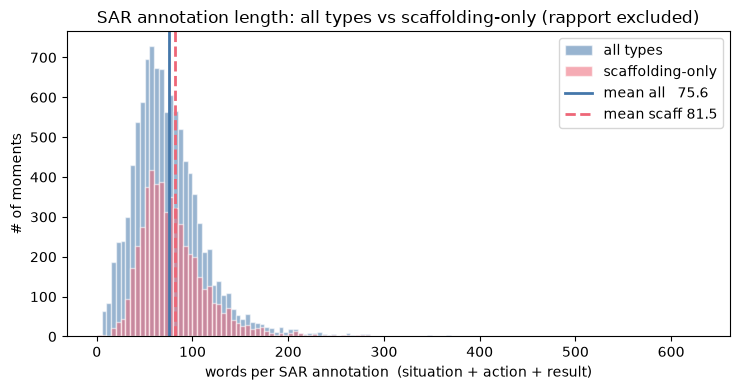

In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Per-annotation SAR word counts (gold moments), split by annotation type.
arr_all   = np.array(sar_gt)
arr_scaff = np.array([sar_tokens(m) for _, m in moments if m["annotation_type"] == "scaffolding"])
arr_rapp  = np.array([sar_tokens(m) for _, m in moments if m["annotation_type"] == "rapport"])

def describe(name, a):
    pct = "  ".join(f"p{p}={np.percentile(a, p):.0f}" for p in (50, 90, 95, 99))
    print(f"{name:18s} n={len(a):5d}  mean={a.mean():5.1f}  median={np.median(a):5.1f}  "
          f"std={a.std():5.1f}  max={a.max():4d}  >200w={ (a>200).mean()*100:4.1f}%   {pct}")

describe("all types", arr_all)
describe("scaffolding-only", arr_scaff)
describe("rapport-only", arr_rapp)

bins = range(0, int(arr_all.max()) + 10, 5)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(arr_all,   bins=bins, color="#4477aa", alpha=0.55, edgecolor="white", label="all types")
ax.hist(arr_scaff, bins=bins, color="#ee6677", alpha=0.55, edgecolor="white", label="scaffolding-only")
ax.axvline(arr_all.mean(),   color="#4477aa", lw=2,          label=f"mean all   {arr_all.mean():.1f}")
ax.axvline(arr_scaff.mean(), color="#ee6677", lw=2, ls="--", label=f"mean scaff {arr_scaff.mean():.1f}")
ax.set_xlabel("words per SAR annotation  (situation + action + result)")
ax.set_ylabel("# of moments")
ax.set_title("SAR annotation length: all types vs scaffolding-only (rapport excluded)")
ax.legend()
plt.tight_layout()
plt.show()
